# Optimisers

This is the breadth tour of the optimiser families. Every optimiser shares the same call —
`optimise(estimator)` (or `optimise(estimator, rd)` for the naive and meta ones) — and returns
a result whose `w` field holds the asset weights. The point of this page is to show the *shape*
of each family with one minimal call; for objectives, risk measures, variants, and trade-offs,
follow the cross-links into the [optimiser examples](../examples/3_optimisers/01_MeanRisk_Objectives.md).

We fix one empirical prior and reuse it everywhere so the families are comparable.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

X = TimeArray(CSV.File(joinpath(@__DIR__, "../examples/SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

Solver
         name ┼ Symbol: :clarabel
       solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
     settings ┼ Dict{String, Bool}: Dict{String, Bool}("verbose" => 0)
    check_sol ┼ @NamedTuple{allow_local::Bool, allow_almost::Bool}: (allow_local = true, allow_almost = true)
  add_bridges ┴ Bool: true


## 1. Naive optimisers

Naive optimisers use simple, solver-free rules that buy robustness through unsophistication.
`InverseVolatility` weights by the reciprocal of each asset's volatility;
`EqualWeighted` splits capital evenly; `RandomWeighted` samples a Dirichlet
allocation. They take the `ReturnsResult` directly.

In [2]:
res_iv = optimise(InverseVolatility(), rd)
res_ew = optimise(EqualWeighted(), rd)

NaiveOptimisationResult
       oe ┼ DataType: DataType
       pr ┼ nothing
       wb ┼ WeightBounds
          │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
          │   ub ┴ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
  retcode ┼ OptimisationSuccess
          │   res ┴ nothing
        w ┼ 20-element Vector{Float64}
       fb ┴ nothing


## 2. JuMP optimisers — `MeanRisk`

JuMP optimisers solve a mathematical program and are the most flexible on constraints,
objectives, and risk measures. They need a `JuMPOptimiser` carrying the prior and a
`Solver` (we recommend [Clarabel](https://github.com/oxfordcontrol/Clarabel.jl) for
non-MIP problems). The workhorse is `MeanRisk`; its default objective is
`MinimumRisk`.

In [3]:
res_mr = optimise(MeanRisk(; obj = MinimumRisk(),
                           opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

`MeanRisk` also offers `MaximumUtility`, `MaximumRatio` and
`MaximumReturn` objectives and efficient frontiers — see
[MeanRisk Objectives](../examples/3_optimisers/01_MeanRisk_Objectives.md) and
[Efficient Frontier](../examples/3_optimisers/02_Efficient_Frontier.md).

The **risk measure** is the `r` field (of `MeanRisk` and of the clustering optimisers below); the
default is `Variance`. Which family you pick encodes *what kind* of risk you penalise:

  - **Moment-based** — `Variance`, `StandardDeviation`, and higher-moment
    measures. Cheap and classic; the right default when returns are roughly symmetric and you care
    about overall dispersion.
  - **Quantile / tail** — `ConditionalValueatRisk`, `EntropicValueatRisk`,
    `RelativisticValueatRisk`, … Reach for these when the *left tail* matters more than
    overall spread ([Exotic Tail Risk Measures](../examples/3_optimisers/08_Exotic_Tail_Risk_Measures.md)).
  - **OWA (ordered-weight)** — `OrderedWeightsArray` measures weight the whole ordered loss
    distribution, the most general family
    ([OWA Risk Measures](../examples/3_optimisers/05_OWA_Risk_Measures.md)).

You can mix several in one objective ([Multiple Risk Measures](../examples/3_optimisers/04_Multiple_Risk_Measures.md)).
**Drawdown** measures (`MaximumDrawdown`, `ConditionalDrawdownatRisk`, …) penalise
peak-to-trough paths ([Drawdown Risk Measures](../examples/3_optimisers/07_Drawdown_Risk_Measures.md));
the same drawdown notion is also useful purely as a *post-optimisation diagnostic* — via
`drawdowns` on a realised book — when you want to measure rather than optimise it
([Performance Attribution](../examples/6_post_processing/03_Performance_Attribution.md)).

The other JuMP families follow the same `opt = JuMPOptimiser(...)` pattern:

  - `RiskBudgeting` / `RelaxedRiskBudgeting` — target a risk contribution per
    asset or factor ([Risk Budgeting](../examples/3_optimisers/09_Risk_Budgeting.md)).
  - `NearOptimalCentering` — a robust point near the efficient frontier
    ([Near Optimal Centering](../examples/3_optimisers/15_Near_Optimal_Centering.md)).

Here is the minimal risk-budgeting call (equal risk contribution by default):

In [4]:
res_rb = optimise(RiskBudgeting(; opt = JuMPOptimiser(; pe = pr, slv = slv)))

RiskBudgetingResult
   jr ┼ JuMPOptimisationResult
      │        oe ┼ DataType: DataType
      │        pa ┼ ProcessedJuMPOptimiserAttributes
      │           │        pr ┼ LowOrderPrior
      │           │           │         X ┼ 252×20 Matrix{Float64}
      │           │           │        mu ┼ 20-element Vector{Float64}
      │           │           │     sigma ┼ 20×20 Matrix{Float64}
      │           │           │      chol ┼ nothing
      │           │           │         w ┼ nothing
      │           │           │       ens ┼ nothing
      │           │           │       kld ┼ nothing
      │           │           │        ow ┼ nothing
      │           │           │        rr ┼ nothing
      │           │           │      f_mu ┼ nothing
      │           │           │   f_sigma ┼ nothing
      │           │           │       f_w ┴ nothing
      │           │        wb ┼ WeightBounds
      │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Fl

### Which risk measures each optimiser family accepts

Compatibility is a property of the optimiser *family*, not the individual optimiser: every
JuMP optimiser accepts the same `RiskMeasure`s, and clustering optimisers additionally
accept the hierarchical-only measures. You can ask programmatically with
`supports_risk_measure` / `supported_risk_measures`:

```julia
supports_risk_measure(MeanRisk, ConditionalValueatRisk)   # true
supported_risk_measures(HierarchicalRiskParity)           # OptimisationRiskMeasure
```

The table below is *generated* from that same predicate, so it can never drift from what the
optimisers actually dispatch on. Meta-optimisers (`NestedClustered`, `Stacking`,
`SubsetResampling`) are omitted because their acceptance is instance-specific: they *delegate*,
accepting a measure only when every constituent optimiser does (the intersection of their
children's categories).

In [5]:
using InteractiveUtils
# Leaf risk-measure types (concrete or parametric) under a supertype.
function _leaf_risk_measures(T, acc = Type[])
    subs = subtypes(T)
    if isempty(subs)
        push!(acc, T)
    else
        for S in subs
            _leaf_risk_measures(S, acc)
        end
    end
    return acc
end
rms = sort(unique(vcat(_leaf_risk_measures(RiskMeasure),
                       _leaf_risk_measures(HierarchicalRiskMeasure))); by = nameof)
tick(x) = x ? "✓" : ""
pretty_table(DataFrame("Risk measure" => String.(nameof.(rms)),
                       "JuMP (MeanRisk, RiskBudgeting, NOC, FRC)" =>
                           [tick(supports_risk_measure(MeanRisk, M)) for M in rms],
                       "Clustering (HRP, HERC, SCHRP)" =>
                           [tick(supports_risk_measure(HierarchicalRiskParity, M))
                            for M in rms]))

┌───────────────────────────────────────────────────┬───────────────────────────
│                                      Risk measure │ JuMP (MeanRisk, RiskBudg ⋯
│                                            String │                          ⋯
├───────────────────────────────────────────────────┼───────────────────────────
│                                   AverageDrawdown │                          ⋯
│                          BrownianDistanceVariance │                          ⋯
│                         ConditionalDrawdownatRisk │                          ⋯
│                            ConditionalValueatRisk │                          ⋯
│                       ConditionalValueatRiskRange │                          ⋯
│   DistributionallyRobustConditionalDrawdownatRisk │                          ⋯
│      DistributionallyRobustConditionalValueatRisk │                          ⋯
│ DistributionallyRobustConditionalValueatRiskRange │                          ⋯
│                           

## 3. Clustering optimisers

Clustering optimisers build the allocation from the asset correlation hierarchy instead of a
single program. They take a `HierarchicalOptimiser` carrying the prior and a clustering
estimate. `HierarchicalRiskParity` (HRP) is the canonical one;
`HierarchicalEqualRiskContribution` and
`SchurComplementHierarchicalRiskParity` are its siblings — see
[Clustering Optimisers](../examples/3_optimisers/11_Clustering_Optimisers.md).

In [6]:
clr = clusterise(ClustersEstimator(), pr.X)
hopt = HierarchicalOptimiser(; pe = pr, cle = clr)
res_hrp = optimise(HierarchicalRiskParity(; opt = hopt, r = Variance()))

HierarchicalResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      clr ┼ Clusters
          │   res ┼ Clustering.Hclust{Float64}([-1 -13; -2 1; … ; 15 16; 18 17], [0.2992796916890263, 0.3905612031361099, 0.4116454947407609, 0.22529867864314176, 0.48924055164900887, 0.28518628966607656, 0.38008631653392483, 0.58425801808901, 0.4209146698909511, 0.4605479608276049, 0.491265779899127, 0.5080236207888611, 0.6028393326616824, 0.24670816017739164, 0.5174631833197462, 0.6821605083740293, 0.739945604975504, 0.9602133336085281, 1.0707389175241802], [5, 20,

## 4. Meta-optimisers

Meta-optimisers compose other optimisers. `NestedClustered` (NCO) runs an **inner**
optimiser within each cluster and an **outer** optimiser across the cluster representatives;
`Stacking` and `SubsetResampling` blend several fits — see
[Meta Optimisers](../examples/3_optimisers/13_Meta_Optimisers.md). The inner optimiser carries
the prior; the outer one does not.

In [7]:
res_nco = optimise(NestedClustered(; pe = pr, cle = clr,
                                   opti = MeanRisk(; obj = MinimumRisk(),
                                                   opt = JuMPOptimiser(; pe = pr,
                                                                       slv = slv)),
                                   opto = MeanRisk(; obj = MinimumRisk(),
                                                   opt = JuMPOptimiser(; slv = slv))), rd)

NestedClusteredResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      clr ┼ Clusters
          │   res ┼ Clustering.Hclust{Float64}([-1 -13; -2 1; … ; 15 16; 18 17], [0.2992796916890263, 0.3905612031361099, 0.4116454947407609, 0.22529867864314176, 0.48924055164900887, 0.28518628966607656, 0.38008631653392483, 0.58425801808901, 0.4209146698909511, 0.4605479608276049, 0.491265779899127, 0.5080236207888611, 0.6028393326616824, 0.24670816017739164, 0.5174631833197462, 0.6821605083740293, 0.739945604975504, 0.9602133336085281, 1.0707389175241802], [5, 

## 5. Comparing the families

One prior, six optimisers, six allocations. The naive rules, risk budgeting, and the clustering
hierarchy spread weight broadly (max weight in single digits to low teens); `MeanRisk(MinimumRisk)`
and NCO concentrate into a few low-variance names (max weight ≈ a third). Same data, very
different portfolios — which is the point of having a menu.

                        Weights by optimiser family
┌────────┬─────────┬─────────┬──────────┬────────────┬──────────┬──────────┐
│  Asset │  InvVol │  EqualW │  MinRisk │ RiskBudget │      HRP │      NCO │
│ String │ Float64 │ Float64 │  Float64 │    Float64 │  Float64 │  Float64 │
├────────┼─────────┼─────────┼──────────┼────────────┼──────────┼──────────┤
│   AAPL │ 4.004 % │   5.0 % │    0.0 % │    3.313 % │   3.26 % │    0.0 % │
│    AMD │ 2.332 % │   5.0 % │    0.0 % │    2.277 % │  1.263 % │    0.0 % │
│    BAC │  4.39 % │   5.0 % │    0.0 % │     3.98 % │  3.356 % │    0.0 % │
│    BBY │ 3.143 % │   5.0 % │    0.0 % │    3.245 % │  2.871 % │    0.0 % │
│    CVX │ 4.326 % │   5.0 % │  7.432 % │    5.173 % │  3.937 % │  3.213 % │
│     GE │ 4.087 % │   5.0 % │  0.806 % │    3.971 % │  3.879 % │  0.507 % │
│     HD │  4.55 % │   5.0 % │    0.0 % │    4.181 % │  2.605 % │  4.411 % │
│    JNJ │ 8.175 % │   5.0 % │ 36.974 % │    8.222 % │ 13.136 % │ 31.816 % │
│    JPM │ 4.771 % │   5

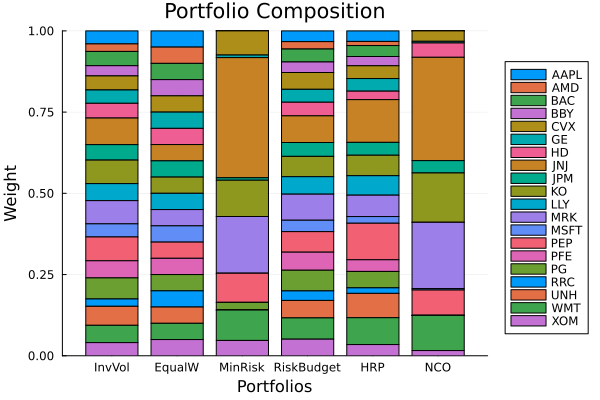

In [8]:
results = [res_iv, res_ew, res_mr, res_rb, res_hrp, res_nco]
labels = ["InvVol", "EqualW", "MinRisk", "RiskBudget", "HRP", "NCO"]

pretty_table(DataFrame(["Asset" => rd.nx,
                        [labels[i] => results[i].w for i in eachindex(results)]...]);
             formatters = [resfmt], title = "Weights by optimiser family")

plot_stacked_bar_composition(results, rd; xticks = (1:length(labels), labels))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*